# Hiệu suất mô hình theo dataset và so sánh tuned tại `MAX_LEN=768`

Notebook này tổng hợp hai nhóm kết quả:

- So sánh CNN-only, LSTM-only, CNN–LSTM tuần tự và CNN–LSTM song song trên từng tập test tương ứng với dataset dùng để train.
- So sánh công bằng CNN-only và CNN–LSTM sau tuning tại `MAX_LEN=768` trên test nội bộ và tập external `additional_obfu_merged.csv`.

Các bảng được đọc từ artifact đã lưu; tuning chỉ chạy lại khi thiếu artifact cuối cùng.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'cnn_lstm' / 'CNN_LSTM.py').is_file() and (candidate / 'cnn_only' / 'train_cnn_only.py').is_file():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root.')

PROJECT_ROOT = find_project_root(Path.cwd())
MAX_LEN = 768
MAX_TRIALS = 8
TUNING_EPOCHS = 12
FINAL_EPOCHS = 50
CNN_ONLY_ROOT = PROJECT_ROOT / 'cnn_only' / 'artifacts_cnn_only_tuning_768' / 'obfu_http'
CNN_LSTM_ROOT = PROJECT_ROOT / 'cnn_lstm' / 'artifacts_cnn_lstm_tuning_768' / 'obfu_http'
CNN_ONLY_FINAL = CNN_ONLY_ROOT / 'final'
CNN_LSTM_FINAL = CNN_LSTM_ROOT / 'final'
EXTERNAL_DATASET = PROJECT_ROOT / 'analysis' / 'obfu_eval_outputs' / 'additional_obfu_merged.csv'
REPORT_ROOT = PROJECT_ROOT / 'reports' / 'tuned_additional_obfu_evaluation_768'

CNN_ONLY_MODEL = CNN_ONLY_FINAL / 'best_cnn_only.keras'
CNN_LSTM_MODEL = CNN_LSTM_FINAL / 'best_tuned_hybrid_cnn_lstm.keras'
RUN_CNN_ONLY_TUNING = not (CNN_ONLY_FINAL / 'metadata_and_results.json').is_file()
RUN_CNN_LSTM_TUNING = not (CNN_LSTM_FINAL / 'metadata_and_results.json').is_file()
comparison_path = REPORT_ROOT / 'comparison.csv'
latest_model_time = max([path.stat().st_mtime for path in (CNN_ONLY_MODEL, CNN_LSTM_MODEL) if path.is_file()] or [0])
RUN_EXTERNAL_TEST = (not comparison_path.is_file()) or comparison_path.stat().st_mtime < latest_model_time

assert EXTERNAL_DATASET.is_file(), EXTERNAL_DATASET
print('Python:', sys.executable)
print('Project:', PROJECT_ROOT)
print('MAX_LEN:', MAX_LEN)
print('External dataset:', EXTERNAL_DATASET)
print('Run CNN-only tuning:', RUN_CNN_ONLY_TUNING)
print('Run CNN-LSTM tuning:', RUN_CNN_LSTM_TUNING)
print('Run external test:', RUN_EXTERNAL_TEST)

Python: C:\Users\admin\Desktop\obfuscated-web-attack-detection\.venv-webapp\Scripts\python.exe
Project: C:\Users\admin\Desktop\obfuscated-web-attack-detection
MAX_LEN: 768
External dataset: C:\Users\admin\Desktop\obfuscated-web-attack-detection\analysis\obfu_eval_outputs\additional_obfu_merged.csv
Run CNN-only tuning: False
Run CNN-LSTM tuning: False
Run external test: False


## 1. Hiệu suất các mô hình theo từng dataset

Chỉ lấy các dòng `train_source == test_source` để thể hiện hiệu suất in-domain. CNN–LSTM song song hiện có artifact cho Kaggle và CSIC; ô OBFU_HTTP được để trống thay vì nội suy.

,model,dataset,accuracy,auc_roc,attack_precision,attack_recall,attack_f1
0,CNN-only,kaggle,0.996604,0.999885,0.997550,0.997193,0.997372
1,LSTM-only,kaggle,0.998154,0.999943,0.998266,0.998877,0.998572
2,CNN-LSTM tuần tự,kaggle,0.998451,0.999921,0.998877,0.998724,0.998801
3,CNN-LSTM song song,kaggle,0.997132,0.999848,0.997907,0.997653,0.997780
4,CNN-only,csic,0.990011,0.999487,0.994340,0.981249,0.987751
5,LSTM-only,csic,0.992713,0.999509,0.995572,0.986635,0.991083
6,CNN-LSTM tuần tự,csic,0.994923,0.999671,0.998389,0.989228,0.993788
7,CNN-LSTM song song,csic,0.997298,0.999823,0.998199,0.995212,0.996704
8,CNN-only,obfu_http,0.999780,0.999999,0.999853,0.999707,0.999780
9,LSTM-only,obfu_http,0.999634,0.999980,0.999707,0.999560,0.999634


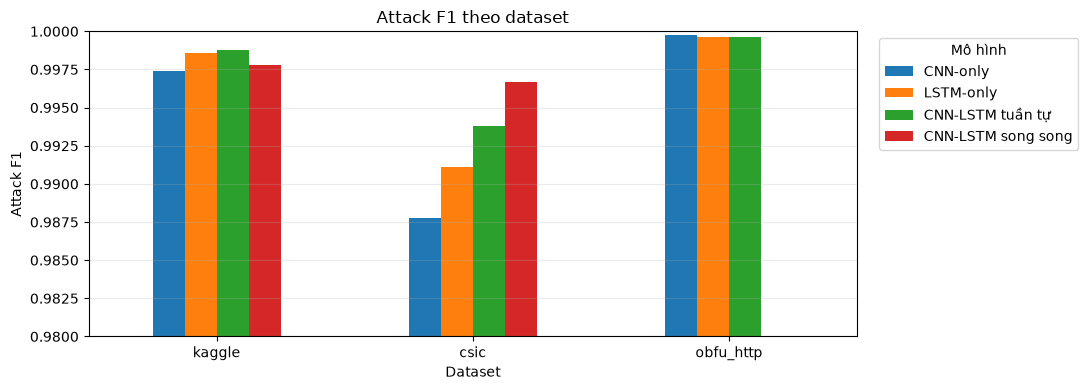

In [2]:
model_sources = [
    ('CNN-only', PROJECT_ROOT / 'cnn_only' / 'artifacts_cnn_only_by_dataset' / 'cross_eval_results.csv'),
    ('LSTM-only', PROJECT_ROOT / 'lstm_only' / 'artifacts_lstm_only_by_dataset' / 'cross_eval_results.csv'),
    ('CNN-LSTM tuần tự', PROJECT_ROOT / 'cnn_lstm' / 'artifacts_cnn_lstm_by_dataset' / 'cross_eval_results.csv'),
]

rows = []
for model_name, csv_path in model_sources:
    frame = pd.read_csv(csv_path)
    frame = frame.loc[frame['train_source'] == frame['test_source']].copy()
    frame['model'] = model_name
    frame['dataset'] = frame['test_source']
    rows.append(frame[['model', 'dataset', 'accuracy', 'auc_roc', 'attack_precision', 'attack_recall', 'attack_f1']])

parallel_path = PROJECT_ROOT / 'cnn_lstm_parallel' / 'artifacts' / 'dataset_comparison.csv'
parallel = pd.read_csv(parallel_path)
parallel['model'] = 'CNN-LSTM song song'
rows.append(parallel[['model', 'dataset', 'accuracy', 'auc_roc', 'attack_precision', 'attack_recall', 'attack_f1']])

model_by_dataset = pd.concat(rows, ignore_index=True)
dataset_order = ['kaggle', 'csic', 'obfu_http']
model_order = ['CNN-only', 'LSTM-only', 'CNN-LSTM tuần tự', 'CNN-LSTM song song']
model_by_dataset['dataset'] = pd.Categorical(model_by_dataset['dataset'], dataset_order, ordered=True)
model_by_dataset['model'] = pd.Categorical(model_by_dataset['model'], model_order, ordered=True)
model_by_dataset = model_by_dataset.sort_values(['dataset', 'model']).reset_index(drop=True)

display(model_by_dataset.style.format({
    'accuracy': '{:.6f}', 'auc_roc': '{:.6f}',
    'attack_precision': '{:.6f}', 'attack_recall': '{:.6f}', 'attack_f1': '{:.6f}',
}).set_caption('Hiệu suất in-domain trên test split của từng dataset'))

attack_f1_pivot = model_by_dataset.pivot(index='dataset', columns='model', values='attack_f1')
axis = attack_f1_pivot.plot(kind='bar', figsize=(11, 4), ylim=(0.98, 1.0), rot=0)
axis.set_title('Attack F1 theo dataset')
axis.set_xlabel('Dataset')
axis.set_ylabel('Attack F1')
axis.grid(axis='y', alpha=0.25)
axis.legend(title='Mô hình', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 1. Hàm chạy tuning có checkpoint

Mỗi trial chạy trong một tiến trình riêng để giải phóng bộ nhớ TensorFlow. Kết quả từng trial được lưu ngay sau khi hoàn thành.

In [3]:
ENV = dict(os.environ, TF_CPP_MIN_LOG_LEVEL='2')

def run_tuning(script, output_root, label):
    common = [
        sys.executable, '-u', str(script),
        '--output-dir', str(output_root),
        '--max-len', str(MAX_LEN),
        '--max-trials', str(MAX_TRIALS),
        '--tuning-epochs', str(TUNING_EPOCHS),
        '--final-epochs', str(FINAL_EPOCHS),
    ]
    for trial in range(1, MAX_TRIALS + 1):
        print(f'\n===== {label}: trial {trial}/{MAX_TRIALS} =====', flush=True)
        subprocess.run(common + ['--only-trial', str(trial)], cwd=PROJECT_ROOT, env=ENV, check=True)
    print(f'\n===== {label}: train lại cấu hình tốt nhất =====', flush=True)
    subprocess.run(common + ['--final-only'], cwd=PROJECT_ROOT, env=ENV, check=True)

## 2. Tuning và train lại CNN-only tại 768

In [4]:
if RUN_CNN_ONLY_TUNING:
    run_tuning(PROJECT_ROOT / 'cnn_only' / 'tune_cnn_only.py', CNN_ONLY_ROOT, 'CNN-only 768')
else:
    print('CNN-only 768 đã hoàn thành:', CNN_ONLY_FINAL)

CNN-only 768 đã hoàn thành: C:\Users\admin\Desktop\obfuscated-web-attack-detection\cnn_only\artifacts_cnn_only_tuning_768\obfu_http\final


## 3. Tuning và train lại CNN–LSTM tại 768

In [5]:
if RUN_CNN_LSTM_TUNING:
    run_tuning(PROJECT_ROOT / 'cnn_lstm' / 'tune_cnn_lstm.py', CNN_LSTM_ROOT, 'CNN-LSTM 768')
else:
    print('CNN-LSTM 768 đã hoàn thành:', CNN_LSTM_FINAL)

CNN-LSTM 768 đã hoàn thành: C:\Users\admin\Desktop\obfuscated-web-attack-detection\cnn_lstm\artifacts_cnn_lstm_tuning_768\obfu_http\final


## 4. Kiểm tra tính công bằng và kết quả tuning

Cell này dừng ngay nếu hai model không dùng đúng 768 hoặc không dùng cùng các file split.

In [6]:
def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

cnn_protocol = read_json(CNN_ONLY_ROOT / 'search_protocol.json')
hybrid_protocol = read_json(CNN_LSTM_ROOT / 'search_protocol.json')
assert cnn_protocol['max_len'] == hybrid_protocol['max_len'] == MAX_LEN
assert cnn_protocol['split_sha256'] == hybrid_protocol['split_sha256']
assert cnn_protocol['seed'] == hybrid_protocol['seed'] == 42

cnn_model = tf.keras.models.load_model(CNN_ONLY_MODEL, compile=False)
hybrid_model = tf.keras.models.load_model(CNN_LSTM_MODEL, compile=False)
assert int(cnn_model.input_shape[1]) == int(hybrid_model.input_shape[1]) == MAX_LEN
del cnn_model, hybrid_model
tf.keras.backend.clear_session()

for label, root in [('CNN-only', CNN_ONLY_ROOT), ('CNN-LSTM', CNN_LSTM_ROOT)]:
    trials = pd.read_csv(root / 'tuning_results.csv').sort_values(
        ['val_attack_f1_at_0_5', 'min_val_loss'], ascending=[False, True]
    ).reset_index(drop=True)
    best = read_json(root / 'best_hyperparameters.json')
    print(f'\n{label} — cấu hình được chọn:', best)
    display(trials.drop(columns=['checkpoint']).style.format({
        'min_val_loss': '{:.6f}', 'val_attack_f1_at_0_5': '{:.6f}'
    }))
print('\nĐạt kiểm tra: cùng split, seed=42, threshold=0.5 và MAX_LEN=768.')


CNN-only — cấu hình được chọn: {'embedding_dim': 64, 'cnn_filters': 128, 'dense_units': 32, 'dropout': 0.4, 'learning_rate': 0.001, 'batch_size': 256}


,trial,embedding_dim,cnn_filters,dense_units,dropout,learning_rate,batch_size,epochs_ran,min_val_loss,val_attack_f1_at_0_5,parameter_count
0,8,64,128,32,0.400000,0.001000,256,10,0.000686,0.999927,118081
1,1,64,128,64,0.300000,0.001000,128,12,0.000369,0.999927,122241
2,7,32,128,64,0.400000,0.001000,128,9,0.000812,0.999927,106369
3,6,32,64,32,0.200000,0.000300,128,12,0.001079,0.999707,32449
4,5,32,128,32,0.200000,0.000300,256,12,0.001671,0.999560,102209
5,3,64,64,64,0.400000,0.000300,128,10,0.001426,0.999560,44289
6,4,64,128,32,0.400000,0.001000,128,6,0.002008,0.999341,118081
7,2,32,64,64,0.200000,0.000300,256,12,0.002030,0.999120,34561



CNN-LSTM — cấu hình được chọn: {'embedding_dim': 32, 'cnn_filters': 128, 'lstm_units': 128, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.001, 'batch_size': 128}


,trial,embedding_dim,cnn_filters,lstm_units,dense_units,dropout,learning_rate,batch_size,epochs_ran,min_val_loss,val_attack_f1_at_0_5,parameter_count
0,8,32,128,128,64,0.400000,0.001000,128,6,0.000858,0.999780,237953
1,1,64,128,128,64,0.300000,0.001000,128,6,0.001038,0.999634,253825
2,4,64,128,64,32,0.400000,0.001000,128,8,0.001202,0.999560,165441
3,5,64,64,64,64,0.400000,0.000300,128,8,0.001547,0.999341,77313
4,6,32,128,128,32,0.200000,0.000300,256,9,0.002128,0.999341,233793
5,7,32,64,128,32,0.200000,0.000300,128,10,0.003788,0.999120,133313
6,2,32,64,64,64,0.200000,0.000300,256,7,0.007958,0.997800,67585
7,3,64,64,128,64,0.400000,0.000300,128,4,0.017501,0.995586,147201



Đạt kiểm tra: cùng split, seed=42, threshold=0.5 và MAX_LEN=768.


## 5. Kết quả test nội bộ sau khi train lại

Test nội bộ chỉ được đọc sau khi cấu hình thắng đã được chọn.

In [7]:
internal_rows = []
for label, final_dir in [('CNN-only tuned 768', CNN_ONLY_FINAL), ('CNN-LSTM tuned 768', CNN_LSTM_FINAL)]:
    metadata = read_json(final_dir / 'metadata_and_results.json')
    result = metadata['evaluation']['test']
    report = result['classification_report']
    tn, fp = result['confusion_matrix'][0]
    fn, tp = result['confusion_matrix'][1]
    internal_rows.append({
        'model': label, 'max_len': metadata['model']['max_len'],
        'accuracy': result['accuracy'], 'roc_auc': result['auc_roc'],
        'attack_precision': report['Attack (1)']['precision'],
        'attack_recall': report['Attack (1)']['recall'],
        'attack_f1': report['Attack (1)']['f1-score'],
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    })
display(pd.DataFrame(internal_rows).style.format({
    'accuracy': '{:.6f}', 'roc_auc': '{:.6f}',
    'attack_precision': '{:.6f}', 'attack_recall': '{:.6f}', 'attack_f1': '{:.6f}'
}))

,model,max_len,accuracy,roc_auc,attack_precision,attack_recall,attack_f1,tn,fp,fn,tp
0,CNN-only tuned 768,768,0.999194,0.999998,0.999707,0.998681,0.999194,6823,2,9,6815
1,CNN-LSTM tuned 768,768,0.999414,1.000000,0.998829,1.000000,0.999414,6817,8,0,6824


## 6. External test trên `additional_obfu_merged.csv`

Dataset này không được dùng để fit tokenizer, tuning, chọn threshold hoặc train. Evaluator xác nhận checkpoint và metadata đều có input 768 trước khi dự đoán.

In [8]:
if RUN_EXTERNAL_TEST:
    evaluator = PROJECT_ROOT / 'analysis' / 'evaluate_tuned_pair_768.py'
    subprocess.run([
        sys.executable, '-u', str(evaluator),
        '--dataset', str(EXTERNAL_DATASET),
        '--cnn-only-dir', str(CNN_ONLY_FINAL),
        '--cnn-lstm-dir', str(CNN_LSTM_FINAL),
        '--output-dir', str(REPORT_ROOT),
        '--max-len', str(MAX_LEN),
    ], cwd=PROJECT_ROOT, env=ENV, check=True)
else:
    print('External test đã cập nhật:', comparison_path)

External test đã cập nhật: C:\Users\admin\Desktop\obfuscated-web-attack-detection\reports\tuned_additional_obfu_evaluation_768\comparison.csv


In [9]:
comparison_768 = pd.read_csv(comparison_path)
metric_formats = {
    'accuracy': '{:.6f}', 'roc_auc': '{:.6f}', 'average_precision': '{:.6f}',
    'normal_f1': '{:.6f}', 'attack_precision': '{:.6f}',
    'attack_recall': '{:.6f}', 'attack_f1': '{:.6f}',
    'inference_ms_per_sample': '{:.4f}',
}
display(comparison_768.style.format(metric_formats).set_caption(
    'Tuned CNN-only và CNN-LSTM — external additional_obfu_merged.csv — MAX_LEN=768'
))

for model_key in ('cnn_only', 'cnn_lstm'):
    summary = read_json(REPORT_ROOT / model_key / 'summary.json')
    assert summary['max_len'] == MAX_LEN
    assert summary['external_data_used_for_training_or_selection'] is False
    print(
        model_key, '| truncated:', f"{summary['truncated_rows']:,}",
        '| training overlap:', f"{summary['training_overlap_rows']:,}"
    )

,model,max_len,threshold,rows,accuracy,roc_auc,average_precision,normal_f1,attack_precision,attack_recall,attack_f1,tn,fp,fn,tp,truncated_rows,training_overlap_rows,inference_ms_per_sample,summary_path
0,CNN-only tuned 768,768,0.500000,156186,0.709916,0.794117,0.819397,0.713727,0.755272,0.662768,0.706003,56479,17627,27680,54400,27250,0,0.7496,C:\Users\admin\Desktop\obfuscated-web-attack-detection\reports\tuned_additional_obfu_evaluation_768\cnn_only\summary.json
1,CNN-LSTM tuned 768,768,0.500000,156186,0.821777,0.902004,0.895361,0.822259,0.868095,0.779276,0.821291,64387,9719,18117,63963,27250,0,0.7741,C:\Users\admin\Desktop\obfuscated-web-attack-detection\reports\tuned_additional_obfu_evaluation_768\cnn_lstm\summary.json


cnn_only | truncated: 27,250 | training overlap: 0
cnn_lstm | truncated: 27,250 | training overlap: 0


## 7. Đối chiếu tùy chọn với kết quả tuned 1024 hiện có

Bảng này chỉ xuất hiện nếu báo cáo 1024 tồn tại. So sánh chính giữa hai kiến trúc vẫn là bảng 768 ở trên.

In [10]:
comparison_1024_path = PROJECT_ROOT / 'reports' / 'tuned_additional_obfu_evaluation' / 'comparison.csv'
if comparison_1024_path.is_file():
    comparison_1024 = pd.read_csv(comparison_1024_path).copy()
    comparison_1024['experiment'] = 'tuned_1024'
    comparison_768_view = comparison_768.copy()
    comparison_768_view['experiment'] = 'tuned_768'
    shared = [column for column in comparison_768_view.columns if column in comparison_1024.columns]
    display(pd.concat([comparison_768_view[shared], comparison_1024[shared]], ignore_index=True).style.format(metric_formats))
else:
    print('Không tìm thấy comparison 1024; bỏ qua bảng đối chiếu.')

,experiment
0,tuned_768
1,tuned_768
2,tuned_1024
3,tuned_1024
4,tuned_1024
5,tuned_1024
6,tuned_1024
7,tuned_1024


## 8. Learning curves của lần train cuối

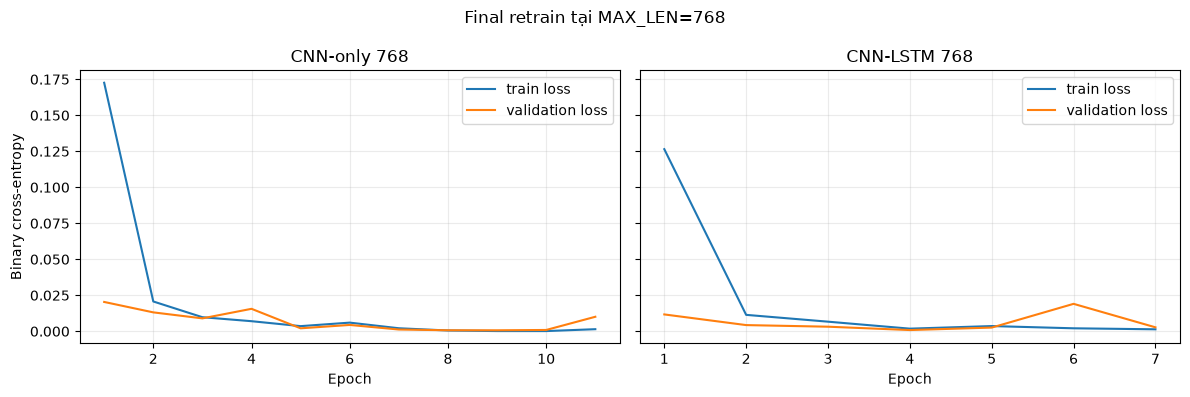

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, (label, final_dir) in zip(axes, [('CNN-only 768', CNN_ONLY_FINAL), ('CNN-LSTM 768', CNN_LSTM_FINAL)]):
    history = pd.read_csv(final_dir / 'training_history.csv')
    epochs = range(1, len(history) + 1)
    axis.plot(epochs, history['loss'], label='train loss')
    axis.plot(epochs, history['val_loss'], label='validation loss')
    axis.set_title(label)
    axis.set_xlabel('Epoch')
    axis.grid(alpha=0.25)
    axis.legend()
axes[0].set_ylabel('Binary cross-entropy')
fig.suptitle('Final retrain tại MAX_LEN=768')
fig.tight_layout()
plt.show()

## Artifact đầu ra

- CNN-only: `cnn_only/artifacts_cnn_only_tuning_768/obfu_http/final/`
- CNN–LSTM: `cnn_lstm/artifacts_cnn_lstm_tuning_768/obfu_http/final/`
- External predictions và metrics: `reports/tuned_additional_obfu_evaluation_768/`

Không thay đổi checkpoint của WebApp.